# Hindu Numeral Recognition

CNN classifier for 32x32 grayscale Devanagari digits 0-9. This commit covers data loading, exploration, train/validation split and the data generators.

# Disclaimer
AI tools were used for code completion and Academic writing

## 1. Imports

Standard data-science stack. Random seed fixed across Python, NumPy and TensorFlow so the train/validation split and weight initialisation are reproducible.

In [8]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

## 2. Configuration

All paths and hyperparameters in one place. Images are already 32x32 grayscale, so no resizing is required.

In [9]:
BASE_DIR    = Path('iivp-2026-challenge')
TRAIN_DIR   = BASE_DIR / 'train' / 'train'
TRAIN_CSV   = BASE_DIR / 'train.csv'

IMG_SIZE    = 32
CHANNELS    = 1
BATCH_SIZE  = 128
NUM_CLASSES = 10

## 3. Training labels

`train.csv` lists `Id` and `Category` for every training image. A `filepath` column is built pointing to `train/train/{Category}/{Id}.png` so the data generator can stream the files directly.

In [10]:
df = pd.read_csv(TRAIN_CSV)
df['filepath'] = df.apply(
    lambda r: str(TRAIN_DIR / str(r['Category']) / f"{r['Id']}.png"), axis=1
)
df['Category'] = df['Category'].astype(str)

print(f"Total training samples: {len(df)}")
print("\nClass distribution:")
print(df['Category'].value_counts().sort_index())

Total training samples: 17000

Class distribution:
Category
0    1700
1    1700
2    1700
3    1700
4    1700
5    1700
6    1700
7    1700
8    1700
9    1700
Name: count, dtype: int64


17,000 samples, exactly 1,700 per class. Perfectly balanced - no class weighting needed.

## 4. Sample inspection

One example per class to confirm the files load, are grayscale, and to get a feel for the digit shapes (Devanagari numerals look very different from Western 0-9).

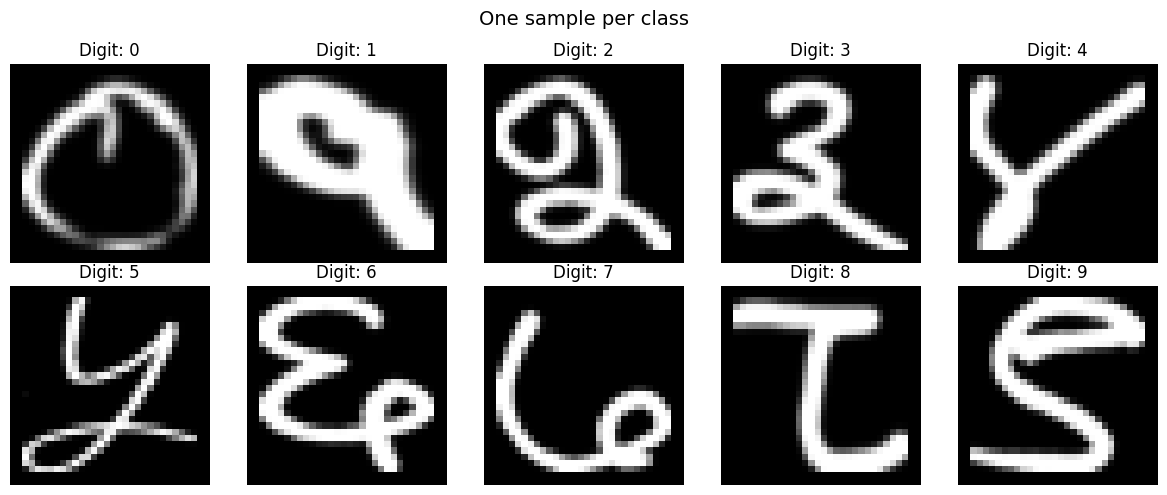

Image shape: (32, 32), dtype: uint8, range: [0, 255]


In [11]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for digit in range(10):
    sample = df[df['Category'] == str(digit)].iloc[0]
    img = Image.open(sample['filepath'])
    ax = axes[digit // 5][digit % 5]
    ax.imshow(img, cmap='gray')
    ax.set_title(f'Digit: {digit}')
    ax.axis('off')
plt.suptitle('One sample per class', fontsize=14)
plt.tight_layout()
plt.show()

sample_arr = np.array(Image.open(df.iloc[0]['filepath']))
print(f"Image shape: {sample_arr.shape}, dtype: {sample_arr.dtype}, range: [{sample_arr.min()}, {sample_arr.max()}]")

Pixel values are uint8 in [0, 255]. The generator below rescales them to [0, 1].

## 5. Train / validation split

10% (1,700 images) held out for validation. Stratified by class so each digit ends up with exactly 170 validation images.

In [12]:
train_df, val_df = train_test_split(
    df, test_size=0.10, stratify=df['Category'], random_state=SEED
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)

print(f"Train: {len(train_df)}  |  Val: {len(val_df)}")
print("Val class distribution:")
print(val_df['Category'].value_counts().sort_index())

Train: 15300  |  Val: 1700
Val class distribution:
Category
0    170
1    170
2    170
3    170
4    170
5    170
6    170
7    170
8    170
9    170
Name: count, dtype: int64


170 per class in val, as expected.

## 6. Data generators

**Training generator:** rescale to [0, 1] plus light augmentation - small rotations, shifts and zooms - to simulate handwriting variation. No flipping: a horizontally flipped Devanagari digit is a different character.

**Validation generator:** rescaling only, no augmentation, for a clean accuracy measurement.

`color_mode='grayscale'` is required - the default is RGB, which would silently load 3-channel images and break the model input shape.

In [13]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    horizontal_flip=False,
    vertical_flip=False,
    fill_mode='nearest'
)
val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_dataframe(
    train_df, x_col='filepath', y_col='Category',
    target_size=(IMG_SIZE, IMG_SIZE), color_mode='grayscale',
    class_mode='sparse', batch_size=BATCH_SIZE, shuffle=True, seed=SEED
)
val_gen = val_datagen.flow_from_dataframe(
    val_df, x_col='filepath', y_col='Category',
    target_size=(IMG_SIZE, IMG_SIZE), color_mode='grayscale',
    class_mode='sparse', batch_size=BATCH_SIZE, shuffle=False
)

Found 15300 validated image filenames belonging to 10 classes.
Found 1700 validated image filenames belonging to 10 classes.


## 7. Batch sanity check

Pull one batch from `train_gen` and confirm the shape is `(128, 32, 32, 1)` and pixel values fall in [0, 1].

In [14]:
x_batch, y_batch = next(train_gen)
print(f"Batch shape: {x_batch.shape}")
print(f"Pixel range after rescaling: [{x_batch.min():.3f}, {x_batch.max():.3f}]")
print(f"Label sample: {y_batch[:10]}")

train_gen.reset()

Batch shape: (128, 32, 32, 1)
Pixel range after rescaling: [0.000, 1.000]
Label sample: [0. 5. 2. 5. 3. 3. 8. 3. 4. 0.]


Data side complete: dataframe loaded, stratified split, augmented generators, batch shape verified.